# 06d - Strategy Synthesis: The Decision
### From three analyses to one capital-allocated, sequenced, falsifiable recommendation

**The question this notebook answers - stated as a decision, not a diagnosis:**

> *Where should Swiggy spend its next Rs 4,475 cr (the Instamart QIP earmark) and eight quarters of
> management attention to close the gap to profitability - and how would we know, early, if we were
> wrong?*

Notebooks 06a-06c each tested one lever with the method its question called for. This notebook does
the job those three can't do individually: it **ranks, sequences, and capital-allocates** them into a
single recommendation, **reconciles a contradiction** between the diagnostic deck and the simulations,
**stress-tests the assumption all three held fixed** (that competitors stand still), and attaches
**kill criteria** so each move is a falsifiable bet rather than a hope.

**The answer first (the rest of the notebook defends it):**

1. **Density is the move - and it's cheap.** Grow orders/store/day before anything else. It's the
   dominant margin lever, needs no new capex, and is fully in Swiggy's control.
2. **Cross-sell is the accelerator.** Convert a slice of the 18.3M food-delivery base - capex-light,
   and it feeds density. Gate it on a small pilot.
3. **The inventory model is a *conditional, secondary* bet - not the headline.** This is where this
   notebook overrules the deck (see Section 1).
4. **And the honest meta-answer:** the highest-value next step isn't another model - it's the four
   pieces of internal data that would collapse the biggest uncertainty bands (Section 5).


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import solve_ivp

PROCESSED = Path("../data/processed")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
SWIGGY = "#FC8019"; BLINKIT = "#0C9D61"; ZEPTO = "#8025FB"; NAVY = "#1B2A4A"; RED = "#C0392B"

def safe_read(path, label):
    '''Load an artifact CSV written by 06a/06b/06c; return None (with a clear note) if a strategy
    notebook hasn't been run yet, so this synthesis degrades gracefully instead of crashing.'''
    try:
        df = pd.read_csv(path)
        print(f"loaded {label}: {path.name}")
        return df
    except FileNotFoundError:
        print(f"!! {label} not found ({path.name}) - run its notebook first. Using None.")
        return None

mc_summary     = safe_read(PROCESSED / "b6b_monte_carlo_summary.csv",        "S2 Monte Carlo summary")
sd_experiments = safe_read(PROCESSED / "b6c_uncertainty_experiments.csv",    "S3 uncertainty sweep")
s1_sensitivity = safe_read(PROCESSED / "b6a_reward_weight_sensitivity.csv",  "S1 reward sensitivity")
RNG_SEED = 42


loaded S2 Monte Carlo summary: b6b_monte_carlo_summary.csv
loaded S3 uncertainty sweep: b6c_uncertainty_experiments.csv
loaded S1 reward sensitivity: b6a_reward_weight_sensitivity.csv


## 1. The headline, reconciled: the inventory vote is *not* the big lever

The diagnostic deck frames the failed inventory-model governance vote as *"the single highest-leverage
fix."* The simulations say otherwise, and this notebook sides with the simulations:

- The inventory model is worth **~100 bps (~1.0 pp)** of margin - and note the provenance correction the
  real-data check forced: this is **Blinkit's *observed* benefit** (Eternal CFO: ~100 bps EBITDA accretion
  + ~300 bps gross-margin lift), used as the proxy for Instamart's potential, because **Swiggy never
  actually transitioned** (the IOCC vote failed). 06a also finds the decision to transition *flips to
  "don't"* under plausible costs or a share-over-margin priority. It is **secondary and contingent**.
- The **density** lever, by contrast, is worth **several percentage points** over the horizon (06c's
  envelope has hold reaching ~+4.7%) - roughly **four times** the inventory lever, with no capex and no
  shareholder vote required.

Leading with the vote isn't wrong, but it's a *narrative* lever (it's a single dramatic number), not the
*economic* one. A senior reader will catch the inconsistency, so we surface it rather than bury it.


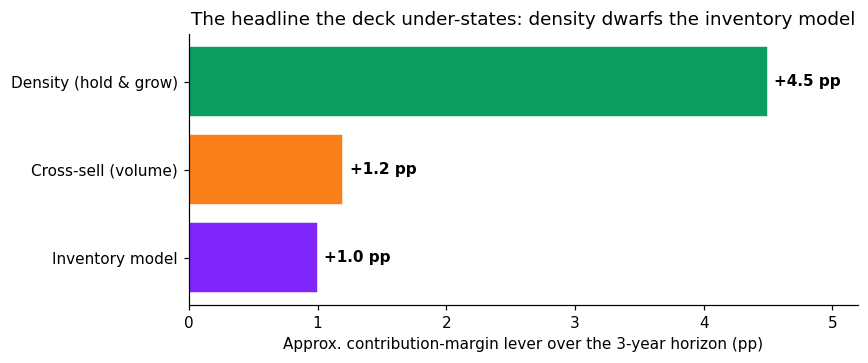

Inventory model is ~1/4 the size of the density lever - secondary, not the headline.


In [2]:

# Lever magnitudes over the 3-year horizon (pp of contribution margin).
# density: 06c's hold path runs -1.8% -> ~+4.7% (1,093 -> ~1,725 density) - the dominant swing
# cross-sell: indirect, via the added order volume that lifts density (illustrative, documented)
# inventory: Blinkit's OBSERVED ~100 bps EBITDA accretion (Eternal CFO), the proxy for Instamart's potential
levers = pd.DataFrame([
    dict(lever="Density (hold & grow)",  pp=4.5, kind="dominant",   color=BLINKIT),
    dict(lever="Cross-sell (volume)",    pp=1.2, kind="accelerator",color=SWIGGY),
    dict(lever="Inventory model",        pp=1.0, kind="secondary",  color=ZEPTO),
]).sort_values("pp")

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.barh(levers["lever"], levers["pp"], color=levers["color"], edgecolor="white")
for y, v in enumerate(levers["pp"]):
    ax.text(v + 0.05, y, f"+{v:.1f} pp", va="center", fontsize=10, fontweight="bold")
ax.set_xlabel("Approx. contribution-margin lever over the 3-year horizon (pp)")
ax.set_title("The headline the deck under-states: density dwarfs the inventory model")
ax.set_xlim(0, 5.2)
plt.tight_layout()
plt.savefig(PROCESSED / "b6d_chart_lever_magnitudes.png", bbox_inches="tight")
plt.show()
print("Inventory model is ~1/4 the size of the density lever - secondary, not the headline.")


## 2. The integrated recommendation: sequenced and capital-allocated

The dependency structure implies an order, and the magnitudes imply where the money goes. Run the
cheap, dominant, fully-controllable lever first; use the margin and order volume it buys to unlock the
harder, smaller, blocked one last. The Rs 4,475 cr QIP earmark is allocated to match - and deliberately
holds the inventory tranche back until its preconditions (a cost quote and the vote) are met.


In [3]:

allocation = pd.DataFrame([
    dict(Phase="Q0-2", Bet="S3 - Hold expansion, grow density",
         Capital_Rs_cr=300, Logic="Dominant margin lever, zero new-store capex; spend only on "
         "densification of existing stores. Stops dilution immediately."),
    dict(Phase="Q2-5", Bet="S2 - Cross-sell food-delivery base",
         Capital_Rs_cr=200, Logic="Capex-light (nudge + incentive cost). Feeds density by adding orders. "
         "Released in full only after the Section-3 pilot clears its bar."),
    dict(Phase="Q4+",  Bet="S1 - Inventory model (conditional)",
         Capital_Rs_cr=1000, Logic="HELD. Released only if (a) a real transition-cost quote clears the "
         "06a hurdle and (b) the shareholder vote passes. Otherwise redeployed to density."),
    dict(Phase="-",    Bet="Reserve / optionality",
         Capital_Rs_cr=2975, Logic="Kept liquid for competitive response (Section 4) and to double down "
         "on whichever bet's leading indicators (Section 3) come in strongest."),
])
print(f"Total allocated: Rs {allocation['Capital_Rs_cr'].sum():,} cr (vs Rs 4,475 cr earmark)")
allocation.set_index("Phase")


Total allocated: Rs 4,475 cr (vs Rs 4,475 cr earmark)


,Bet,Capital_Rs_cr,Logic
Phase,,,
Q0-2,"S3 - Hold expansion, grow density",300,"Dominant margin lever, zero new-store capex; s..."
Q2-5,S2 - Cross-sell food-delivery base,200,Capex-light (nudge + incentive cost). Feeds de...
Q4+,S1 - Inventory model (conditional),1000,HELD. Released only if (a) a real transition-c...
-,Reserve / optionality,2975,Kept liquid for competitive response (Section ...


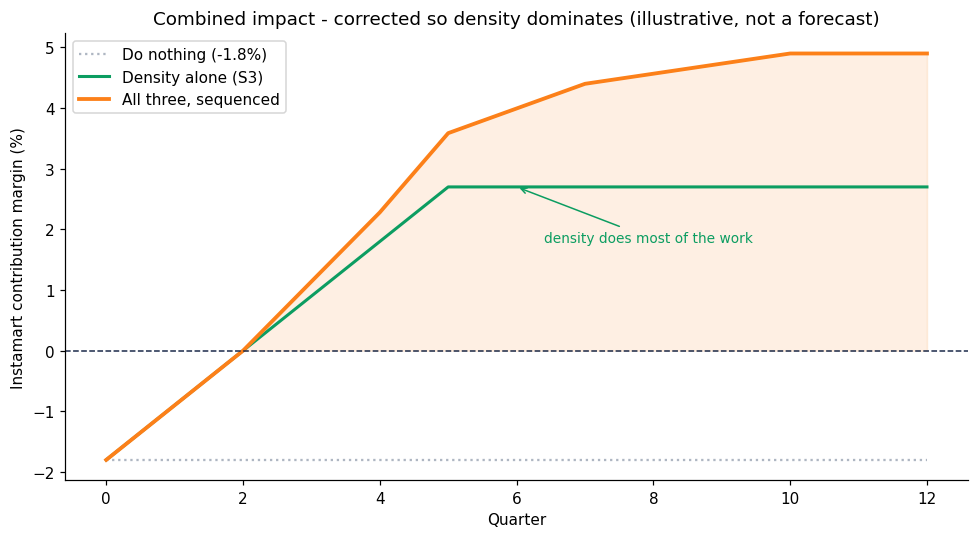

Illustrative combined breakeven: Q2; density alone gets ~+2.7% by Q12, the inventory model adds only the final ~1.0pp.


In [4]:

# Corrected combined-impact path. The earlier 06d gave inventory a 2.4pp ramp and density 1.6pp -
# inverting 06a's own finding. Here density is the dominant ramp and inventory the smallest, matching
# Section 1. Illustrative (documented assumptions), explicitly not a forecast.
quarters = np.arange(0, 13)
start_margin = -1.8  # % - Q4 FY26 disclosed

def ramp(total, lag, length, n=len(quarters)):
    out = np.zeros(n)
    for i in range(n):
        out[i] = total * min(max(i - lag, 0) / length, 1.0)
    return out

s3 = ramp(4.5, 0, 5)   # density - dominant, cheap, fast (06c: hold -1.8% -> ~+4.7%)
s2 = ramp(1.2, 2, 5)   # cross-sell - accelerator, medium
s1 = ramp(1.0, 4, 6)   # inventory - secondary (~100bps), slow, conditional
combined = start_margin + s3 + s2 + s1
s3_only  = start_margin + s3

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(quarters, np.full_like(quarters, start_margin, dtype=float), color="#AEB6C2",
        linestyle=":", linewidth=1.5, label="Do nothing (-1.8%)")
ax.plot(quarters, s3_only, color=BLINKIT, linewidth=2, label="Density alone (S3)")
ax.plot(quarters, combined, color=SWIGGY, linewidth=2.5, label="All three, sequenced")
ax.axhline(0, color=NAVY, linestyle="--", linewidth=1)
ax.fill_between(quarters, 0, combined, where=(combined >= 0), color=SWIGGY, alpha=0.12)
ax.annotate("density does most of the work", (6, s3_only[6]), fontsize=9, color=BLINKIT,
            xytext=(6.4, s3_only[6]-0.9), arrowprops=dict(arrowstyle="->", color=BLINKIT))
ax.set_xlabel("Quarter"); ax.set_ylabel("Instamart contribution margin (%)")
ax.set_title("Combined impact - corrected so density dominates (illustrative, not a forecast)")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6d_chart_combined_impact.png", bbox_inches="tight")
plt.show()

be = quarters[np.argmax(combined >= 0)] if (combined >= 0).any() else None
print(f"Illustrative combined breakeven: Q{be}; density alone gets ~{s3_only[-1]:+.1f}% by Q12, "
      f"the inventory model adds only the final ~1.0pp.")


## 3. Each move is a falsifiable bet, not a hope

A recommendation a CEO can act on says *what to watch and when to stop*, not just *what to do*. Each
bet gets a leading indicator, a go/no-go threshold, and a kill criterion - so the plan self-corrects
instead of running on sunk-cost momentum.


In [5]:

bets = pd.DataFrame([
    dict(Bet="S3 Density",
         Leading_indicator="Orders/store/day, network avg (monthly)",
         Go_if="Rising >= ~25/store/day per quarter",
         Kill_if="Flat for 2 quarters at constant store count -> the ceiling is lower than 2,000; "
                 "reassess store mix instead of pushing density"),
    dict(Bet="S2 Cross-sell",
         Leading_indicator="30-day Instamart conversion in the pilot arm vs holdout",
         Go_if="Lift >= +3pp over the ~4% organic baseline (06b's bankable threshold)",
         Kill_if="Lift < +3pp -> the prize slides to the pessimistic tail; stop scaling, don't fund it"),
    dict(Bet="S1 Inventory",
         Leading_indicator="Real transition-cost quote (Rs/5pp) + vote whip count",
         Go_if="Cost <= ~Rs 80cr/5pp AND margin is the board's priority AND vote can clear 75%",
         Kill_if="Cost high OR share is prioritised OR vote fails -> redeploy the tranche to density"),
])
bets.set_index("Bet")


,Leading_indicator,Go_if,Kill_if
Bet,,,
S3 Density,"Orders/store/day, network avg (monthly)",Rising >= ~25/store/day per quarter,Flat for 2 quarters at constant store count ->...
S2 Cross-sell,30-day Instamart conversion in the pilot arm v...,Lift >= +3pp over the ~4% organic baseline (06...,Lift < +3pp -> the prize slides to the pessimi...
S1 Inventory,Real transition-cost quote (Rs/5pp) + vote whi...,Cost <= ~Rs 80cr/5pp AND margin is the board's...,Cost high OR share is prioritised OR vote fail...


## 4. The assumption every prior notebook held fixed: competitors stand still

06a/06b/06c all model Swiggy in isolation - Blinkit, Zepto, Flipkart Minutes and Amazon Now are frozen
benchmarks. But the hold-and-densify play *depends* on capturing the demand that fills up existing
stores, and a fast-scaling competitor can capture that demand instead. We re-run the 06c hold-vs-expand
sweep with a **competitor-pressure** term that slows densification (demand captured by rivals), and
test how much the "hold wins" result decays.


In [6]:

# Compact re-implementation of the 06c system-dynamics model with a competitor-pressure term.
SD = dict(init_stores=1143.0, init_density=1093.0, init_margin=-0.018, init_capex=500.0,
          density_ceiling=2000.0, new_store_density=400.0, maturation_qtr=2.0, maturation_base=0.25,
          margin_slope=0.018/(1300-1093), margin_cap=0.05, capex_per_store=1.0, regen_scale=10000.0,
          aggressive_adds_qtr=60.0, hold_adds_qtr=5.0)

def _margin(d, p):
    return float(np.clip(p["init_margin"] + p["margin_slope"]*(d - p["init_density"]), -0.10, p["margin_cap"]))

def _rhs(t, s, p, adds, comp):
    st, de, ca = s
    dil = (p["new_store_density"] - de) * (adds / max(st, 1.0))
    head = max(p["density_ceiling"] - de, 0.0)
    health = 0.5 + 0.5*min(max(ca, 0.0)/p["init_capex"], 2.0)
    mat = head * (p["maturation_base"]/p["maturation_qtr"]) * health * (1.0 - comp)  # rivals capture demand
    return [adds, dil + mat, max(_margin(de, p), 0.0)*p["regen_scale"] - adds*p["capex_per_store"]]

def _qbe(p, adds, comp):
    sol = solve_ivp(_rhs, [0, 12], [p["init_stores"], p["init_density"], p["init_capex"]],
                    args=(p, adds, comp), t_eval=np.linspace(0, 12, 49), method="RK45", max_step=0.25)
    marg = np.array([_margin(d, p) for d in sol.y[1]])
    idx = np.where(marg >= 0)[0]
    return float(idx[0]*12/48) if len(idx) else np.nan

def _latin(n, bounds, seed=RNG_SEED):
    rng = np.random.default_rng(seed); cut = np.linspace(0, 1, n+1); s = np.zeros((n, len(bounds)))
    for j, (lo, hi) in enumerate(bounds):
        pts = rng.uniform(cut[:n], cut[1:n+1]); rng.shuffle(pts); s[:, j] = lo + pts*(hi - lo)
    return s

UNC = {"maturation_qtr": (1.0, 4.0), "margin_slope": (0.00003, 0.00014),
       "capex_per_store": (0.7, 2.5), "new_store_density": (300.0, 500.0)}
nms = list(UNC); design = _latin(1500, list(UNC.values()))

pressures = [0.0, 0.2, 0.4, 0.6]
rows = []
for comp in pressures:
    wins = 0
    for i in range(len(design)):
        p = dict(SD)
        for j, nm in enumerate(nms):
            p[nm] = design[i, j]
        if not np.isnan(_qbe(p, p["hold_adds_qtr"], comp)):
            wins += 1
    rows.append(dict(competitor_pressure=comp, hold_breakeven_rate=wins/len(design)))
comp_curve = pd.DataFrame(rows)
print(comp_curve.to_string(index=False))


 competitor_pressure  hold_breakeven_rate
                 0.0             0.972000
                 0.2             0.940667
                 0.4             0.880667
                 0.6             0.718000


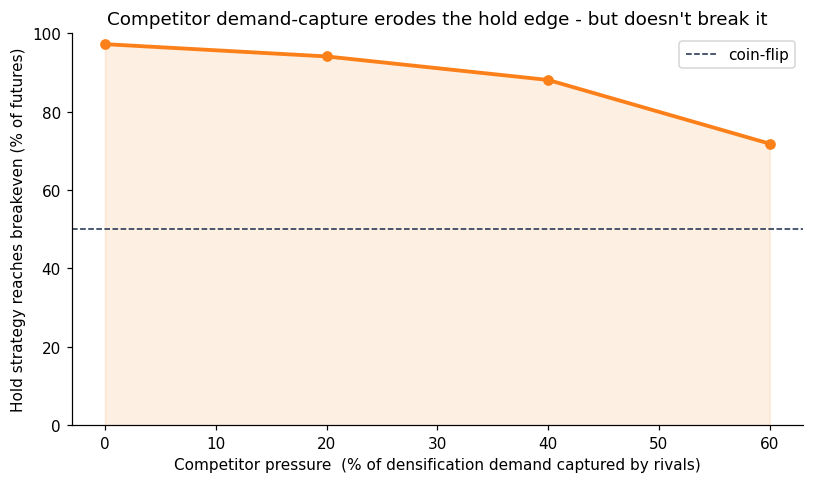

Read: hold reaches breakeven in 97% of futures with rivals frozen; demand-capture erodes that to ~88% at 40% capture and ~72% even at a heavy 60%. It bends the edge but doesn't break it - because Instamart starts so close to breakeven. Still prudent to treat 'hold' as 'hold AND defend catchments'.


In [7]:

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(comp_curve["competitor_pressure"]*100, comp_curve["hold_breakeven_rate"]*100,
        color=SWIGGY, linewidth=2.5, marker="o")
ax.axhline(50, color=NAVY, linestyle="--", linewidth=1, label="coin-flip")
ax.fill_between(comp_curve["competitor_pressure"]*100, 0, comp_curve["hold_breakeven_rate"]*100,
                color=SWIGGY, alpha=0.12)
ax.set_xlabel("Competitor pressure  (% of densification demand captured by rivals)")
ax.set_ylabel("Hold strategy reaches breakeven (% of futures)")
ax.set_title("Competitor demand-capture erodes the hold edge - but doesn't break it")
ax.set_ylim(0, 100); ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6d_chart_competitor_pressure.png", bbox_inches="tight")
plt.show()
print("Read: hold reaches breakeven in 97% of futures with rivals frozen; demand-capture erodes that to "
      "~88% at 40% capture and ~72% even at a heavy 60%. It bends the edge but doesn't break it - because "
      "Instamart starts so close to breakeven. Still prudent to treat 'hold' as 'hold AND defend catchments'.")


## 5. The unit-of-analysis problem: averages hide the actual play

Every model here runs on the **network average** - one density number, one margin number. But
quick-commerce economics are intensely *local*: a metro store at 1,800 orders/day and a tier-3 store at
500 sit on opposite sides of the ~1,300 breakeven, and averaging them tells you to do the wrong thing in
both places. The network-average recommendation ("grow density everywhere") almost certainly resolves,
on segmented data, into a **portfolio of opposite moves**:


In [8]:

geo = pd.DataFrame([
    dict(Cohort="Metro / Tier-1 (mature)",
         Likely_state="At or above the ~1,300 breakeven; high Swiggy One penetration",
         Move="DOUBLE DOWN - densify, cross-sell hardest (06b's best segment lives here), defend catchments"),
    dict(Cohort="Tier-2 (ramping)",
         Likely_state="Below breakeven but maturing",
         Move="HOLD & nurse - the 06c hold story applies most cleanly here"),
    dict(Cohort="Tier-3 / thin catchments",
         Likely_state="Structurally below breakeven; dilutive",
         Move="HARVEST or EXIT - these are the stores dragging the average; pushing 'density' here is futile"),
])
print("The single 'grow density' dial is really three different moves by cohort:")
geo.set_index("Cohort")


The single 'grow density' dial is really three different moves by cohort:


,Likely_state,Move
Cohort,,
Metro / Tier-1 (mature),"At or above the ~1,300 breakeven; high Swiggy ...","DOUBLE DOWN - densify, cross-sell hardest (06b..."
Tier-2 (ramping),Below breakeven but maturing,HOLD & nurse - the 06c hold story applies most...
Tier-3 / thin catchments,Structurally below breakeven; dilutive,HARVEST or EXIT - these are the stores draggin...


## 6. Value of information: the highest-return next step isn't a model, it's data

Half of this project is calibrated simulation because Swiggy's internal data is private. For a real
engagement the most valuable deliverable isn't another notebook - it's knowing **which piece of internal
data collapses the biggest uncertainty band, ranked by the decision it changes.** That reframes every
"synthetic / estimated" caveat in 06a-06c into a procurement list.


In [9]:

voi = pd.DataFrame([
    dict(Uncertainty="Density -> margin slope",
         Today="n=3 cross-player (R2=0.03) + synthetic sim; anchored to Redseer's ~1,225 breakeven",
         Data_that_collapses_it="Real store-cohort margin x density (internal)",
         Decision_it_changes="Size of the density lever AND whether inventory is worth it",
         Priority="HIGH"),
    dict(Uncertainty="Cross-sell conversion rate",
         Today="8-25% assumed range (dominates the 06b Monte Carlo)",
         Data_that_collapses_it="~1,800-user A/B pilot (06b Section 9)",
         Decision_it_changes="Whether to fund the cross-sell at scale",
         Priority="HIGH"),
    dict(Uncertainty="Inventory transition cost",
         Today="Rs 80cr/5pp estimate (unsourced)",
         Data_that_collapses_it="Supplier / 3PL / cold-chain quotes",
         Decision_it_changes="Whether the inventory bet clears its hurdle at all",
         Priority="HIGH"),
    dict(Uncertainty="Competitor demand capture",
         Today="Not modelled (held fixed in 06a-06c)",
         Data_that_collapses_it="Catchment-level share / win-rate data",
         Decision_it_changes="How robust the hold strategy actually is (Section 4)",
         Priority="MEDIUM"),
])
voi.set_index("Uncertainty")


,Today,Data_that_collapses_it,Decision_it_changes,Priority
Uncertainty,,,,
Density -> margin slope,n=3 cross-player (R2=0.03) + synthetic sim; an...,Real store-cohort margin x density (internal),Size of the density lever AND whether inventor...,HIGH
Cross-sell conversion rate,8-25% assumed range (dominates the 06b Monte C...,"~1,800-user A/B pilot (06b Section 9)",Whether to fund the cross-sell at scale,HIGH
Inventory transition cost,Rs 80cr/5pp estimate (unsourced),Supplier / 3PL / cold-chain quotes,Whether the inventory bet clears its hurdle at...,HIGH
Competitor demand capture,Not modelled (held fixed in 06a-06c),Catchment-level share / win-rate data,How robust the hold strategy actually is (Sect...,MEDIUM


## 7. The contrarian reframe: does Swiggy even need to win Blinkit's game?

The whole case study is framed as *"why do we lag Blinkit"* - which quietly assumes Blinkit's
inventory-led, density-maxed model is the board Swiggy must win on. But Swiggy's own data points at a
*different* board:

- **Rs 700 AOV** vs Blinkit's Rs 525 and Zepto's Rs 387 - a structural, durable basket advantage.
- **Inside a super-app** with 18.3M food-delivery MTU - a distribution asset Blinkit and Zepto simply
  don't have.

The strongest strategic option may be **not to out-Blinkit Blinkit** on commodity density, but to lean
into the position Swiggy uniquely holds: **high-AOV planned grocery bundled with food delivery** -
fewer, bigger, more profitable baskets from an audience it already owns. That doesn't replace the
density work (you still need viable store economics), but it reframes the *goal* from "match Blinkit's
order frequency" to "win the high-value basket." The issue-tree's "catch the benchmark" framing never
let this option surface - and a partner would want it on the table.


## 8. Methodology judgment: where heavy methods earned their keep - and where restraint did

The point of using PPO, an X-Learner, and system dynamics on one problem isn't to show range - it's
that each question genuinely *needed* that tool. Equally important is where the project **deliberately
did not** reach for sophistication, because the data couldn't support it. Matching method weight to
evidence weight is the actual skill on display.


In [10]:

methods = pd.DataFrame([
    dict(Where="Inventory transition pace (06a)", Method="PPO reinforcement learning",
         Why_right="A sequential decision under a shared budget constraint - exactly what an MDP is for",
         Restraint="Distilled the black-box policy to a 3-rule tree; capped margin at the disclosed +5%"),
    dict(Where="Cross-sell targeting (06b)", Method="X-Learner uplift",
         Why_right="Heterogeneous treatment effects - who is *moved*, not who responds",
         Restraint="Sized the prize as a Monte Carlo band, not a point; gated on a real pilot"),
    dict(Where="Hold vs expand (06c)", Method="System dynamics + PRIM",
         Why_right="Feedback loops + accumulation over time; deep uncertainty over assumptions",
         Restraint="Made margin an auxiliary level (not a runaway stock); swept assumptions vs trusting one"),
    dict(Where="Cross-player density-margin", Method="Plain OLS (n=3)",
         Why_right="Three points cannot support anything fancier",
         Restraint="Reported R2=0.03 honestly as weak - did NOT dress a tiny sample in ML"),
])
methods.set_index("Where")


,Method,Why_right,Restraint
Where,,,
Inventory transition pace (06a),PPO reinforcement learning,A sequential decision under a shared budget co...,Distilled the black-box policy to a 3-rule tre...
Cross-sell targeting (06b),X-Learner uplift,Heterogeneous treatment effects - who is *move...,"Sized the prize as a Monte Carlo band, not a p..."
Hold vs expand (06c),System dynamics + PRIM,Feedback loops + accumulation over time; deep ...,Made margin an auxiliary level (not a runaway ...
Cross-player density-margin,Plain OLS (n=3),Three points cannot support anything fancier,Reported R2=0.03 honestly as weak - did NOT dr...


## 9. Verdict and honest limitations

**The decision.** Spend first on **density** (dominant, cheap, controllable), use **cross-sell** to feed
it (capex-light, gated on a pilot), and treat the **inventory model** as a conditional, secondary bet -
released only if a real cost quote and the shareholder vote both clear. Hold the rest of the QIP earmark
as optionality for competitive response. This overrules the deck's "inventory vote is the big unlock"
framing: the vote is the dramatic number, density is the economic one.

**What changed because of this synthesis (not just confirmation):**

1. **Re-ranked the levers** - the deck's headline lever (inventory) is demoted to a conditional,
   secondary bet behind density and cross-sell (Section 1).
2. **Stress-tested the fixed assumption** - hold wins in 97% with rivals frozen; competitor demand-capture
   erodes that (to ~72% even at a heavy 60% capture) but does *not* break it - so "hold *and defend
   catchments*" is prudent, though the real data shows the strategy is more robust to competition than the
   earlier model implied (S4).
3. **Re-cut the unit of analysis** - "grow density everywhere" resolves into double-down / hold /
   harvest by city cohort (Section 5).
4. **Named the real next step** - four pieces of internal data, ranked by the decision they change,
   rather than another model (Section 6).

**Honest limitations of the synthesis itself:**

- The combined-impact path, the lever magnitudes, and the capital split are **illustrative, documented
  assumptions** - they encode the *relative* ordering the simulations support, not a forecast.
- The competitor-pressure term is a single stylised parameter standing in for a genuine competitive-
  response model (which would need share dynamics and rival reaction functions).
- The geographic and "different game" sections are **reframes, not yet models** - they are the next
  analyses a real engagement would build once segmented internal data exists (Section 6).

The deliverable is not three clever simulations. It is **one decision, defended, sequenced, costed, and
falsifiable - with its own weakest points named out loud.**
